##**André Veras Fernandes - BEC**

Contexto:

Uma joalheria deseja entender como o peso do diamante em quilates influencia seu
preço em dólares. Para isso, será utilizada uma base de dados contendo características
de diamantes. Nesta atividade, vocês deverão construir um modelo de regressão linear
simples, considerando o preço como variável dependente e o peso do diamante como
variável independente.


Objetivo:

Desenvolver, treinar, interpretar e avaliar um modelo de regressão linear simples para
estimar o preço de um diamante a partir do seu peso.

Entregáveis

O aluno deverá entregar:
1. código em Python comentado;
2. gráficos gerados;
3. equação da reta;
4. métricas de avaliação;
5. respostas interpretativas;
6. conclusão final sobre a utilidade da regressão linear neste problema.


``` py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error,
mean_squared_error
# 1. Carregar os dados
df = pd.read_csv(" Diamond Price Prediction.csv" )
# 2. Selecionar colunas
X = df[[ "Carat (Weight of Daimond)" ]]
y = df[" Price ( in US dollars )"]
# 3. Separar treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size =0.2, random_state=42)
# 4. Criar e treinar o modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# 5. Previsoes
y_pred = modelo.predict(X_test)
# 6. Metricas
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np . sqrt (mse)
print(" Intercepto : " , modelo.intercept_ )
print("Coeficiente angular :", modelo.coef_[0])
print("R2:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
# 7. Grafico de dispersao
plt.figure (figsize =(8,6))
plt.scatter (X_test, y_test, alpha=0.4, label ="Dados reais")
plt.plot ( X_test, y_pred, linewidth=2, label = "Reta de regressao")
plt.xlabel ("Peso do diamante(quilates)")
plt.ylabel(" Preco do diamante ( US$ )")
plt.title("Regressao linear : preco em funcao do peso ")
plt.legend()
plt.show()
```





In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import seaborn as sns

#Tarefas

##Parte 1 — Exploração inicial dos dados
1. Carregue a base de dados no Python.
2. Mostre:

    • as 5 primeiras linhas;

    • os nomes das colunas;

    • o número de linhas e colunas;

    • o tipo de dado de cada coluna.

3. Verifique se há:

    • valores ausentes;

    • valores iguais a zero ou negativos nas colunas de peso e preço.

4. Faça um gráfico de dispersão entre:

    • eixo x: peso do diamante;

    • eixo y: preço do diamante.

In [ ]:
df = pd.read_csv("Diamond Price Prediction.csv")

df.head()


,Carat(Weight of Daimond),Cut(Quality),Color,Clarity,Depth,Table,Price(in US dollars),X(length),Y(width),Z(Depth)
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
print("\nNomes das colunas:", df.columns)
print("\nDimensões (linhas, colunas):", df.shape)
print("\nTipos de dados:\n", df.dtypes)


Nomes das colunas: Index(['Carat(Weight of Daimond)', 'Cut(Quality)', 'Color', 'Clarity', 'Depth',
       'Table', 'Price(in US dollars)', 'X(length)', 'Y(width)', 'Z(Depth)'],
      dtype='object')

Dimensões (linhas, colunas): (53940, 10)

Tipos de dados:
 Carat(Weight of Daimond)    float64
Cut(Quality)                 object
Color                        object
Clarity                      object
Depth                       float64
Table                       float64
Price(in US dollars)          int64
X(length)                   float64
Y(width)                    float64
Z(Depth)                    float64
dtype: object


In [ ]:
print("\nValores ausentes:\n", df.isnull().sum())



Valores ausentes:
 Carat(Weight of Daimond)    0
Cut(Quality)                0
Color                       0
Clarity                     0
Depth                       0
Table                       0
Price(in US dollars)        0
X(length)                   0
Y(width)                    0
Z(Depth)                    0
dtype: int64


In [ ]:
invalidos = df[(df["Carat(Weight of Daimond)"] <= 0) | (df["Price(in US dollars)"] <= 0)]
print(invalidos)

Empty DataFrame
Columns: [Carat(Weight of Daimond), Cut(Quality), Color, Clarity, Depth, Table, Price(in US dollars), X(length), Y(width), Z(Depth)]
Index: []


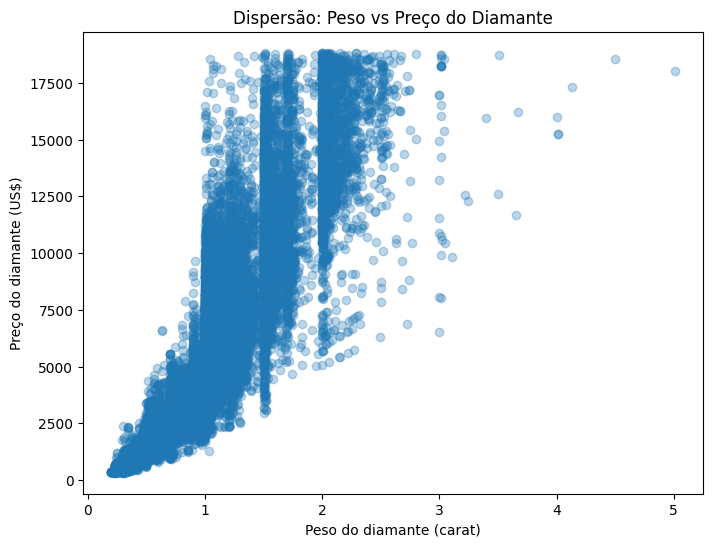

In [ ]:
X = df[['Carat(Weight of Daimond)']]
y = df['Price(in US dollars)']

plt.figure(figsize=(8,6))
plt.scatter(df['Carat(Weight of Daimond)'], df['Price(in US dollars)'], alpha=0.3)

plt.xlabel('Peso do diamante (carat)')
plt.ylabel('Preço do diamante (US$)')
plt.title('Dispersão: Peso vs Preço do Diamante')

plt.show()

**Pergunta para responder:**

A partir do gráfico, a relação entre peso e preço parece linear? Explique brevemente.

Resposta: Não, a relação entre peso e preço parece ser mais expoencial, entre o peso de 0,8 a 1,7 carats aproximadamente, a curva tem um curva com um aumento consideravel, signficicando que o preço aumenta mais que proporcionalmente ao peso.

---

Parte 2 — Construção do modelo

5. Defina:
    
    • variável independente X = peso do diamante;
    
    • variável dependente y = preço do diamante.
6. Separe os dados em:
    
    • treinamento: 80%
    
    • teste: 20%
7. Treine um modelo de regressão linear simples usando LinearRegression do
scikit-learn.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

LinearRegression()

Parte 3 — Equação da reta

8. Obtenha os parâmetros do modelo:
    
    • coeficiente angular
    
    • intercepto
9. Escreva a equação da reta no formato:
   
   $\hat{y} = a + bx$
onde:

   • $\hat{y}$ = preço estimado do diamante;

   • a = intercepto;

   • b = coeficiente angular;

   • x = peso do diamante.


In [ ]:
intercepto = modelo.intercept_
coef_angular = modelo.coef_[0]

print("Intercepto:", modelo.intercept_)
print("Coeficiente angular:", modelo.coef_[0])
print(f"\nEquação da Reta: Preço = {intercepto:.2f} + {coef_angular:.2f} * Peso")

Intercepto: -2261.9117456492177
Coeficiente angular: 7768.910490360821

Equação da Reta: Preço = -2261.91 + 7768.91 * Peso


Pergunta para responder:

Qual é o significado prático do coeficiente angular neste problema?

R: O Coeficiente angular($\beta$) é a variação média esperada em $Y$ para cada aumento unitário em $X$. No caso do problema representa o quanto o preço do diamante varia, em média, para cada aumento de 1 unidade no peso. No caso para cada aumento no peso o preço aumenta em media cerca de 7.768,91 dólares.

---

Parte 4 — Avaliação do modelo

10. Use o modelo para prever os preços no conjunto de teste.

11. Calcule as métricas:
  
  • $R^2$
  
  • MAE

  • MSE
  
  • RMSE

12. Interprete os resultados.

In [ ]:
y_pred = modelo.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R2:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

R2: 0.8489390686155808
MAE: 1009.504742060089
MSE: 2401388.654479092
RMSE: 1549.6414599768207


12 $R^2$: indica a proporção da variabilidade da variável resposta que é explicada pelo modelo.
No caso o modelo explica 84,89% da variação do preço dos diamantes com base no peso, isso indica uma bom ajuste e uma boa relação entre as duas variaveis.

MAE (Erro Absoluto Médio): O modelo erra em média US$1009,50

MSE (Mean Squared Error — Erro Quadrático Médio):
Mede a média dos erros ao quadrado. Esse dado tende a penalizar erros grandes. Significa que o nosso modelo tem alguns erros extremos.

RMSE (Root Mean Squared Error — Raiz do Erro Quadrático Médio): erro médio considerando a raiz do MSE é cerca de US$ 1.549,64. É maior que o MAE então significa que tem uns outliers elevando para acima.

---

Parte 5 — Visualização do ajuste

13. Faça um gráfico contendo:
    
    • os pontos reais do conjunto de teste;
    
    • a reta de regressão ajustada.
14. Interprete visualmente o ajuste do modelo.

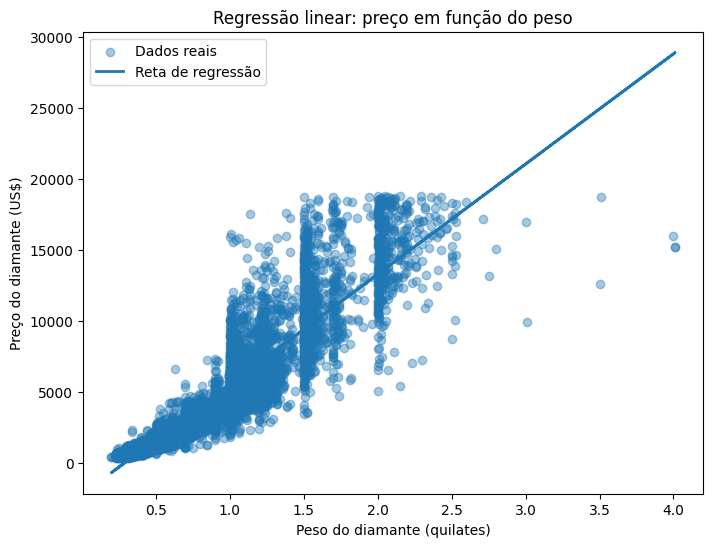

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, alpha=0.4, label="Dados reais")
plt.plot(X_test, y_pred, linewidth=2, label="Reta de regressão")

plt.xlabel("Peso do diamante (quilates)")
plt.ylabel("Preço do diamante (US$)")
plt.title("Regressão linear: preço em função do peso")

plt.legend()
plt.show()

14 R: O resultado indica que o modelo acertou de modo geral a relação mas não explica totalmente, há uma alta variabilidade nos preços para um mesmo peso, sugerindo a ideia de que há mais variaveis influenciando no preço além do peso.


---

Parte 6 — Análise crítica
15. Responda de forma objetiva:
    
    a) Por que este problema é de regressão e não de classificação?
    b) O preço parece aumentar proporcionalmente ao peso em toda a faixa de valores?
    c) Há sinais de dispersão maior dos preços para diamantes mais pesados?
    d) Caso exista heterocedasticidade ou forte assimetria, qual transformação poderia ser testada na variável preço?

a) R: pois não estamos classificando e sim tentando prever algo (no caso o preço)

b) R: Não devido ao fato de que a relação não deve ser linear e pela alta varição nos preços em relação ao peso.

c) R: Sim, a dispersão dos preços é maior para diamantes com peso mais alto

D) R: A transformação logarítmica (usar log(preço)) é comumente usada para reduzir heterocedasticidade e assimetria. Também tem a transformação de Box-Cox que poderia ser usada para normalizar os dados.

---

Desafio extra

16. Aplique uma transformação Box-Cox na variável preço e refaça:
    
    • o gráfico de dispersão;
    
    • a regressão linear.

17. Compare o modelo sem transformação e com transformação.

Lambda: -0.0670


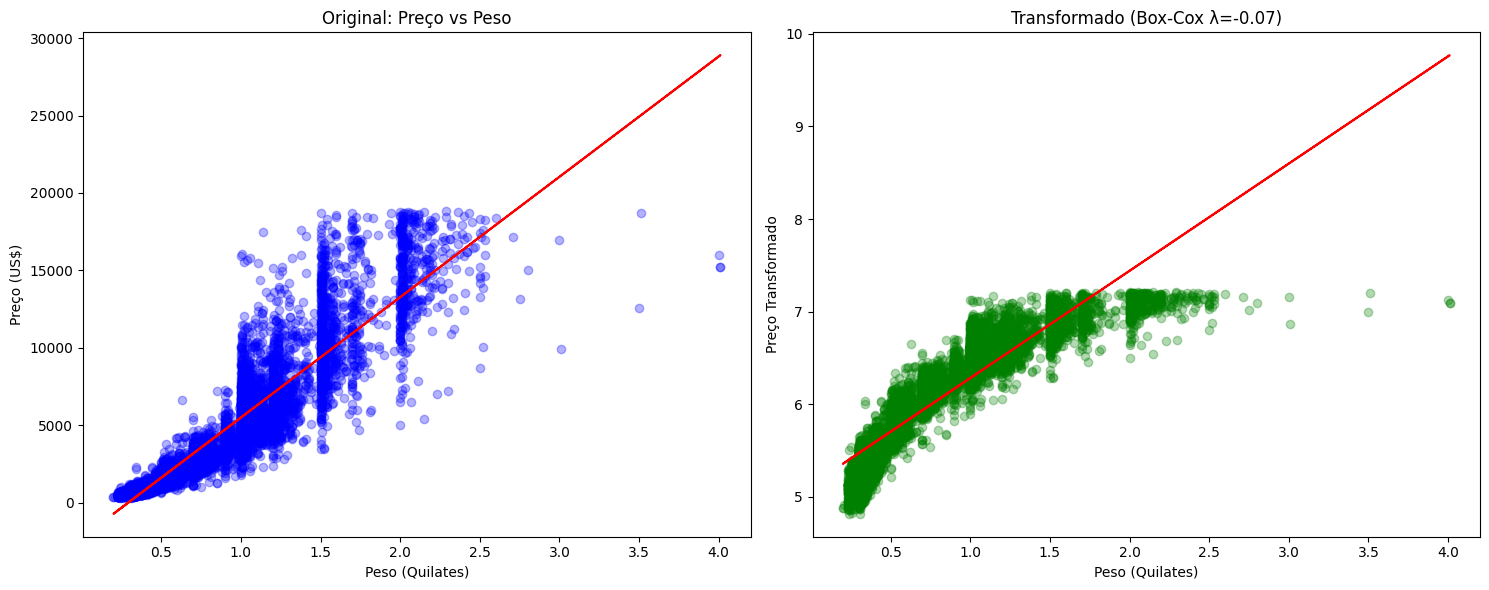

Novo R² com Box-Cox: 0.8337


In [ ]:
from scipy import stats


# Nota: Box-Cox exige dados estritamente positivos.
y_bc, lmbda = stats.boxcox(y)
print(f"Lambda: {lmbda:.4f}")

X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X, y_bc, test_size=0.2, random_state=42
)

modelo_bc = LinearRegression()
modelo_bc.fit(X_train_bc, y_train_bc)
y_pred_bc = modelo_bc.predict(X_test_bc)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Sem Transformação (Original)
ax[0].scatter(X_test, y_test, alpha=0.3, color='blue')
ax[0].plot(X_test, modelo.predict(X_test), color='red', label='Reta Linear')
ax[0].set_title("Original: Preço vs Peso")
ax[0].set_xlabel("Peso (Quilates)")
ax[0].set_ylabel("Preço (US$)")

# Com Transformação Box-Cox
ax[1].scatter(X_test_bc, y_test_bc, alpha=0.3, color='green')
ax[1].plot(X_test_bc, y_pred_bc, color='red', label='Reta Linear (BC)')
ax[1].set_title(f"Transformado (Box-Cox λ={lmbda:.2f})")
ax[1].set_xlabel("Peso (Quilates)")
ax[1].set_ylabel("Preço Transformado")

plt.tight_layout()
plt.show()


r2_bc = r2_score(y_test_bc, y_pred_bc)
print(f"Novo R² com Box-Cox: {r2_bc:.4f}")

Perguntas para responder:

• O padrão visual ficou mais linear após a transformação?

• A dispersão dos resíduos melhorou?

• O novo modelo parece mais adequado?

• O padrão visual ficou mais linear após a transformação?


R: Sim, no gráfico transformado (direito), o padrão melhorou: a nuvem de pontos se aproxima mais de uma reta, especialmente na faixa de 0,25 a ~1,5 quilates, porém ainda há uma curvatura residual.

• A dispersão dos resíduos melhorou?

R: Sim, houve melhora substancial. A transformação com lambda tornou a variância dos resíduos mais constante ao longo dos valores de peso.

• O novo modelo parece mais adequado?

Sim, é mais adequado estatisticamente por diminuir a heterocedasticidade e aproxima a relação de uma linear

---
Pergunta final de reflexão

Mesmo que o peso tenha forte relação com o preço, por que outras variáveis como corte,
cor e pureza também podem ser importantes em um modelo mais realista?

R: pois algumas dessas variaveis pode causar uma diferença entre o valor que o comprador possa ter. alguns exemplos são de que algumas cores são mais raros como os diamantes incolores, ou serem mais bonitos no ponto de vista da pessoa. a pureza indica se há imperfeições ou inclusões, sendo que diamantes mais puros são mais caros e o corte influencia como a luz reflete dentro do diamante, isso pode aumentar o brilho e a aparência visual, tornando o diamante mais valioso.